In [1]:
from collections import Counter
import gzip
import pathlib

import torch
import pandas as pd
import scipy
import numpy as np

import scanpy as sc
import anndata as ad
import gseapy

import seaborn as sns
import matplotlib.pyplot as plt

import flipcrow
import flipcrow.paths
import flipcrow.scp1644_mothership as mship

mps_device = torch.device("mps")

# sc.settings.verbosity = 0
import warnings
warnings.filterwarnings("ignore")

sc.set_figure_params(figsize=(10, 10))

%matplotlib inline

1.10.0rc2


In [2]:
filter_savepoint = 'scp1644_filter_savepoint.h5ad'
scp1644_filter = ad.read_h5ad(str(flipcrow.paths.DATA_PATH / "SCP1644" / filter_savepoint))

Text(0.5, 1.0, 'Figure S1D - median pct_counts_mt 9.42')

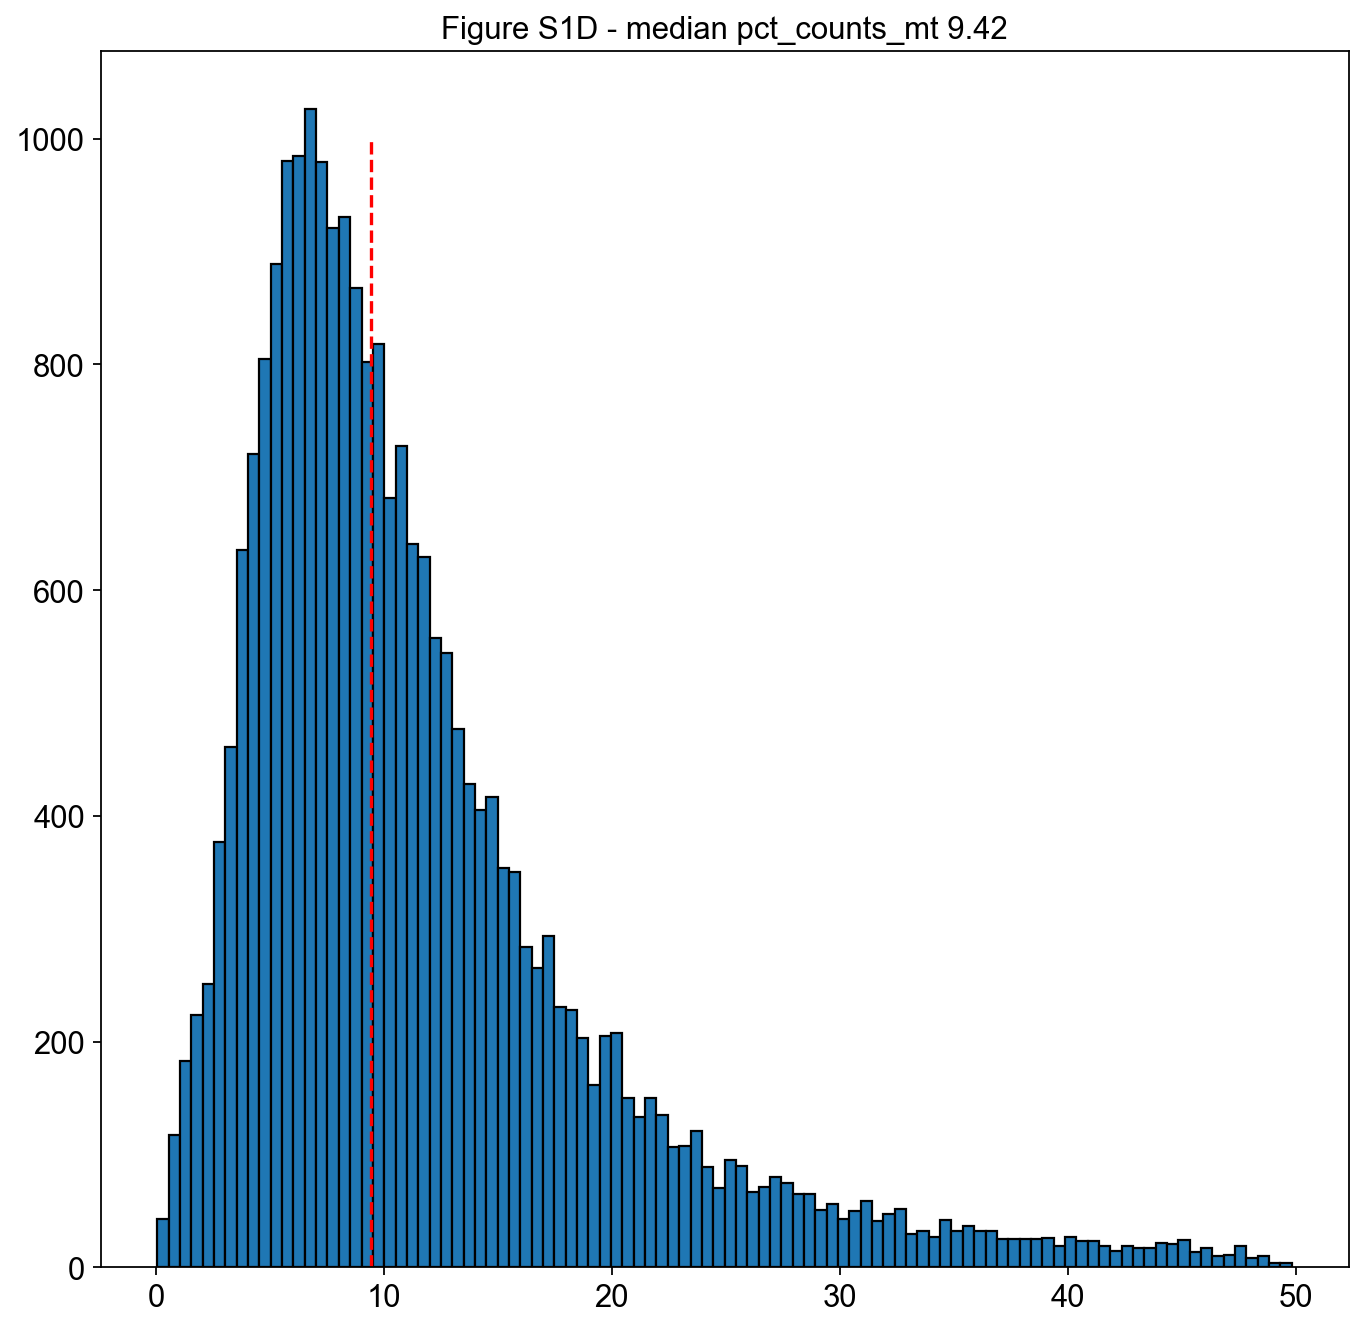

In [5]:
plt.hist(scp1644_filter.obs.pct_counts_mt, bins=100, edgecolor='k')
mt_med = np.median(scp1644_filter.obs.pct_counts_mt)
plt.grid(False)
plt.plot([mt_med, mt_med], [0, 1000], 'r--')
plt.title(f'Figure S1D - median pct_counts_mt {mt_med:.2f}')

In [7]:
scp1644_filter.obs['log10_total_counts'] = np.log10(scp1644_filter.obs.total_counts)

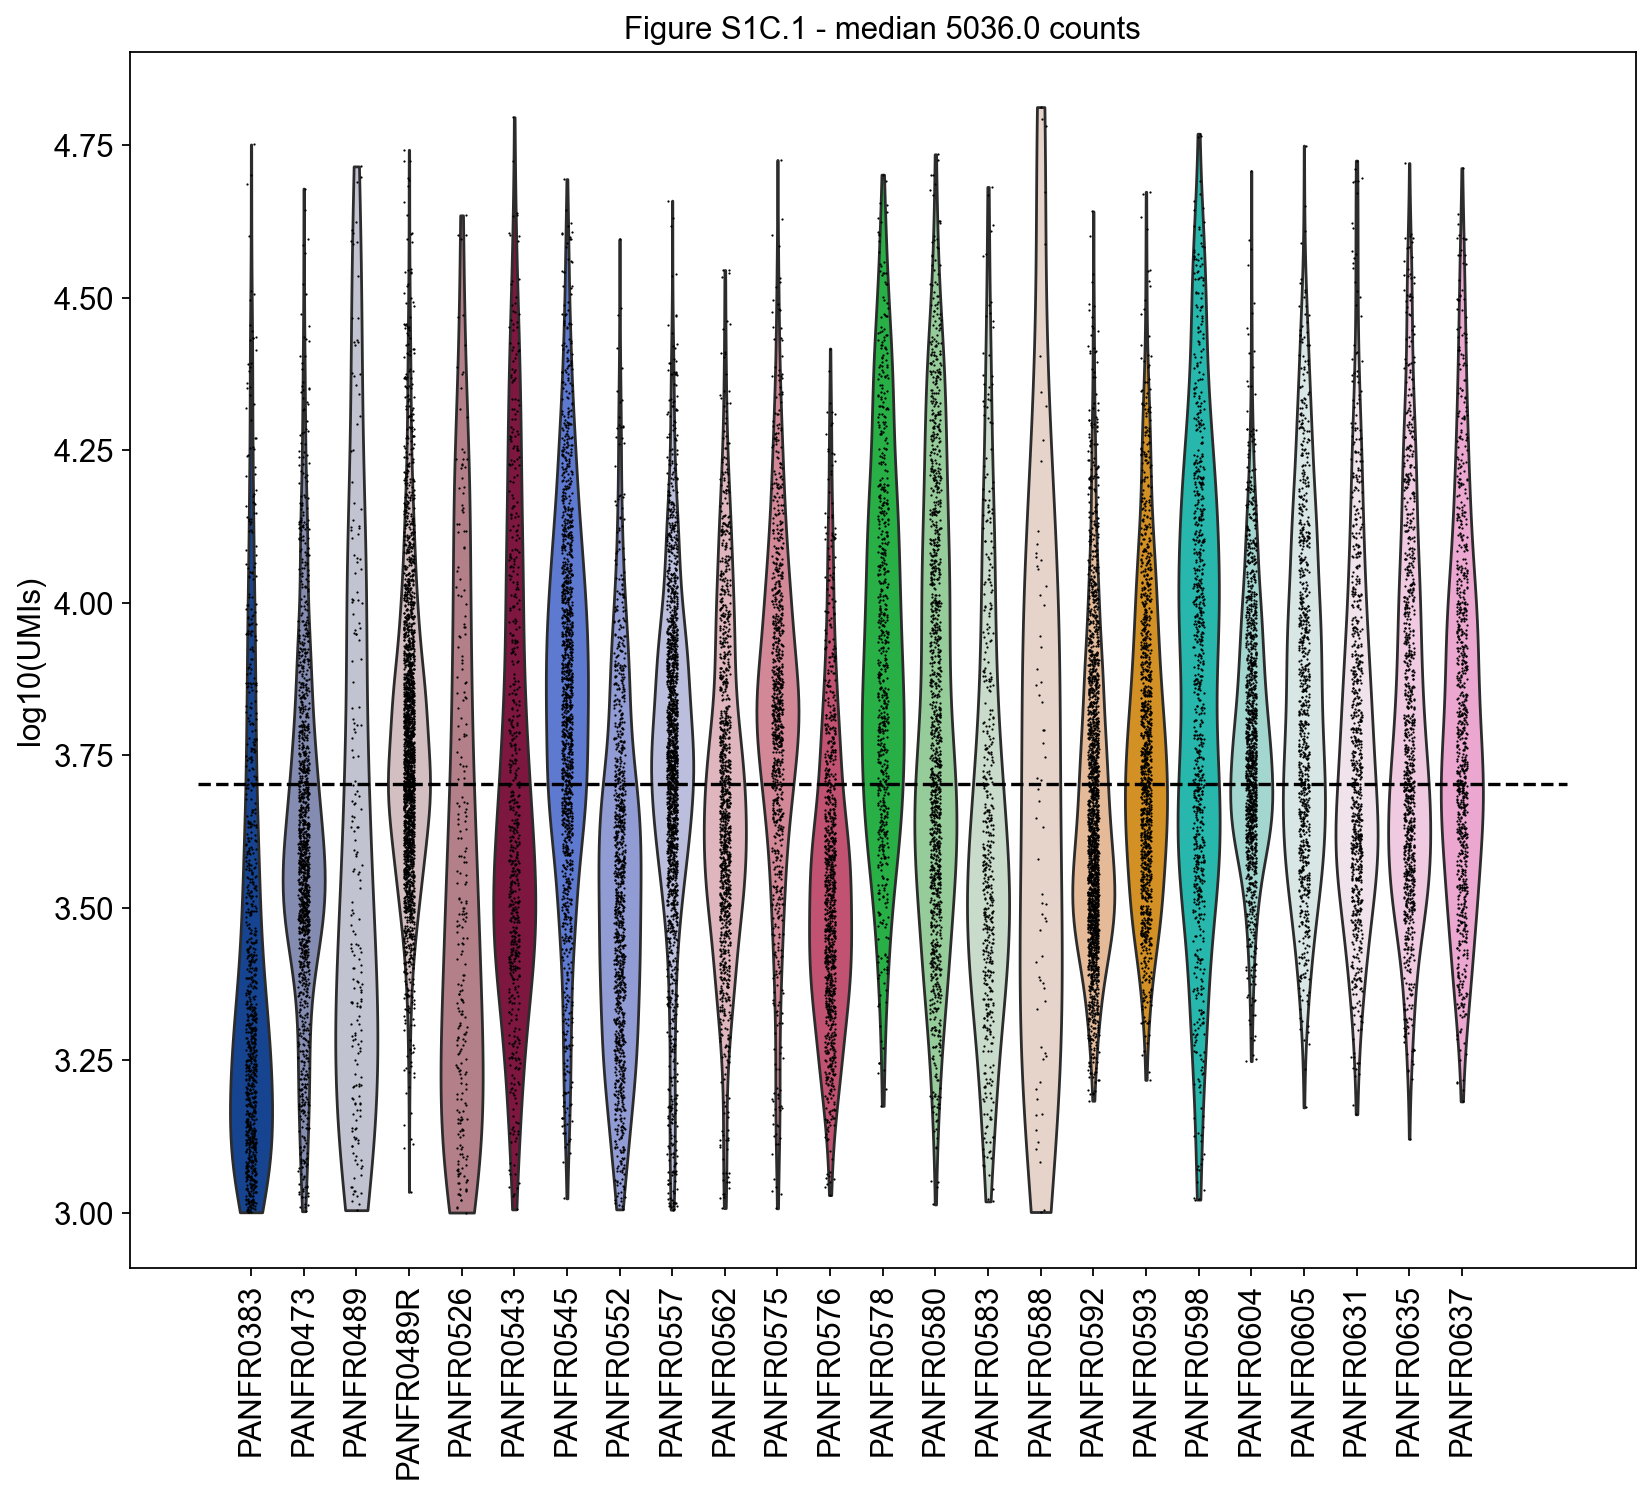

In [8]:
log10_ct_median = np.median(scp1644_filter.obs.log10_total_counts)
ct_median = np.median(scp1644_filter.obs.total_counts)
ax = sc.pl.violin(scp1644_filter, keys='log10_total_counts', groupby='donor_ID', rotation=90, show=False) 
ax.plot([-1, len(scp1644_filter.obs.donor_ID.unique())+1], [log10_ct_median, log10_ct_median], 'k--')
ax.set_title(f'Figure S1C.1 - median {ct_median} counts')
ax.set_ylabel('log10(UMIs)')
plt.grid(False)


In [9]:
print(scp1644_filter.obs.Genes)
scp1644_filter.obs.Genes = scp1644_filter.obs.Genes.astype(int)

Biopsy_PANFR0592_T2_1_AAAAGAGCGGCA    2914
Biopsy_PANFR0592_T2_1_AAAATTACATGT    6002
Biopsy_PANFR0592_T2_1_AAAGACCCAGTT    2112
Biopsy_PANFR0592_T2_1_AAAGATGGTGTC    1448
Biopsy_PANFR0592_T2_1_AAAGCAATTGAT    3382
                                      ... 
Biopsy_PANFR0637_T1_TTTCTGTCTGGT      3475
Biopsy_PANFR0637_T1_TTTGAAAAGCCA      2946
Biopsy_PANFR0637_T1_TTTGAAGGCAAT      2065
Biopsy_PANFR0637_T1_TTTGTGACGCAA      3455
Biopsy_PANFR0637_T1_TTTTGTTTCATG      1543
Name: Genes, Length: 24113, dtype: category
Categories (5349, object): ['430', '435', '441', '447', ..., '8162', '8171', '8189', '8213']


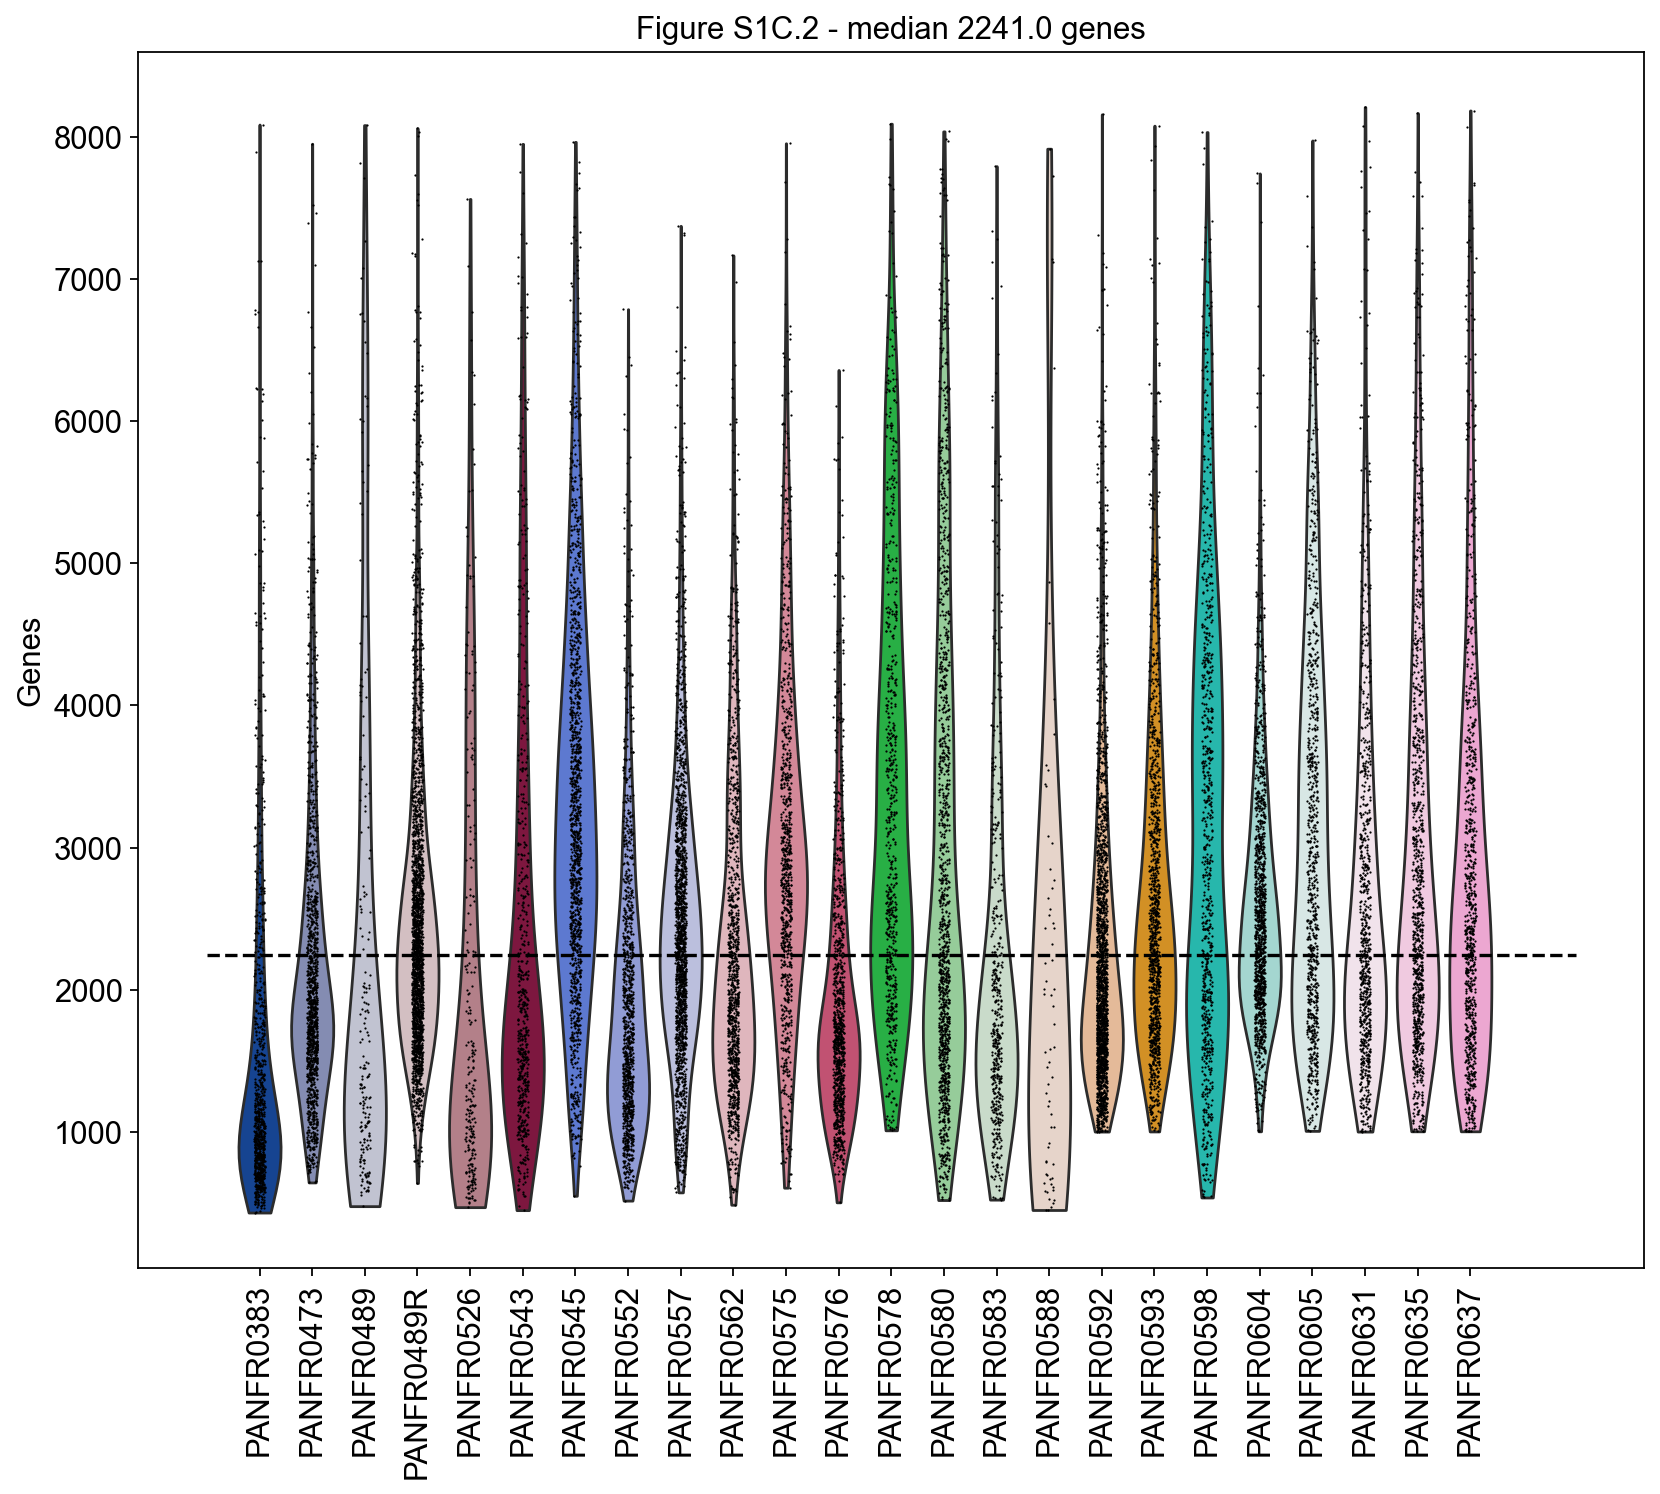

In [12]:
genes_median = np.median(scp1644_filter.obs.Genes.astype(float))
ax = sc.pl.violin(scp1644_filter, keys='Genes', groupby='donor_ID', rotation=90, show=False) 
ax.plot([-1, len(scp1644_filter.obs.donor_ID.unique())+1], [genes_median, genes_median], 'k--')
ax.set_title(f'Figure S1C.2 - median {genes_median} genes')
plt.grid(False)

Final tSNE


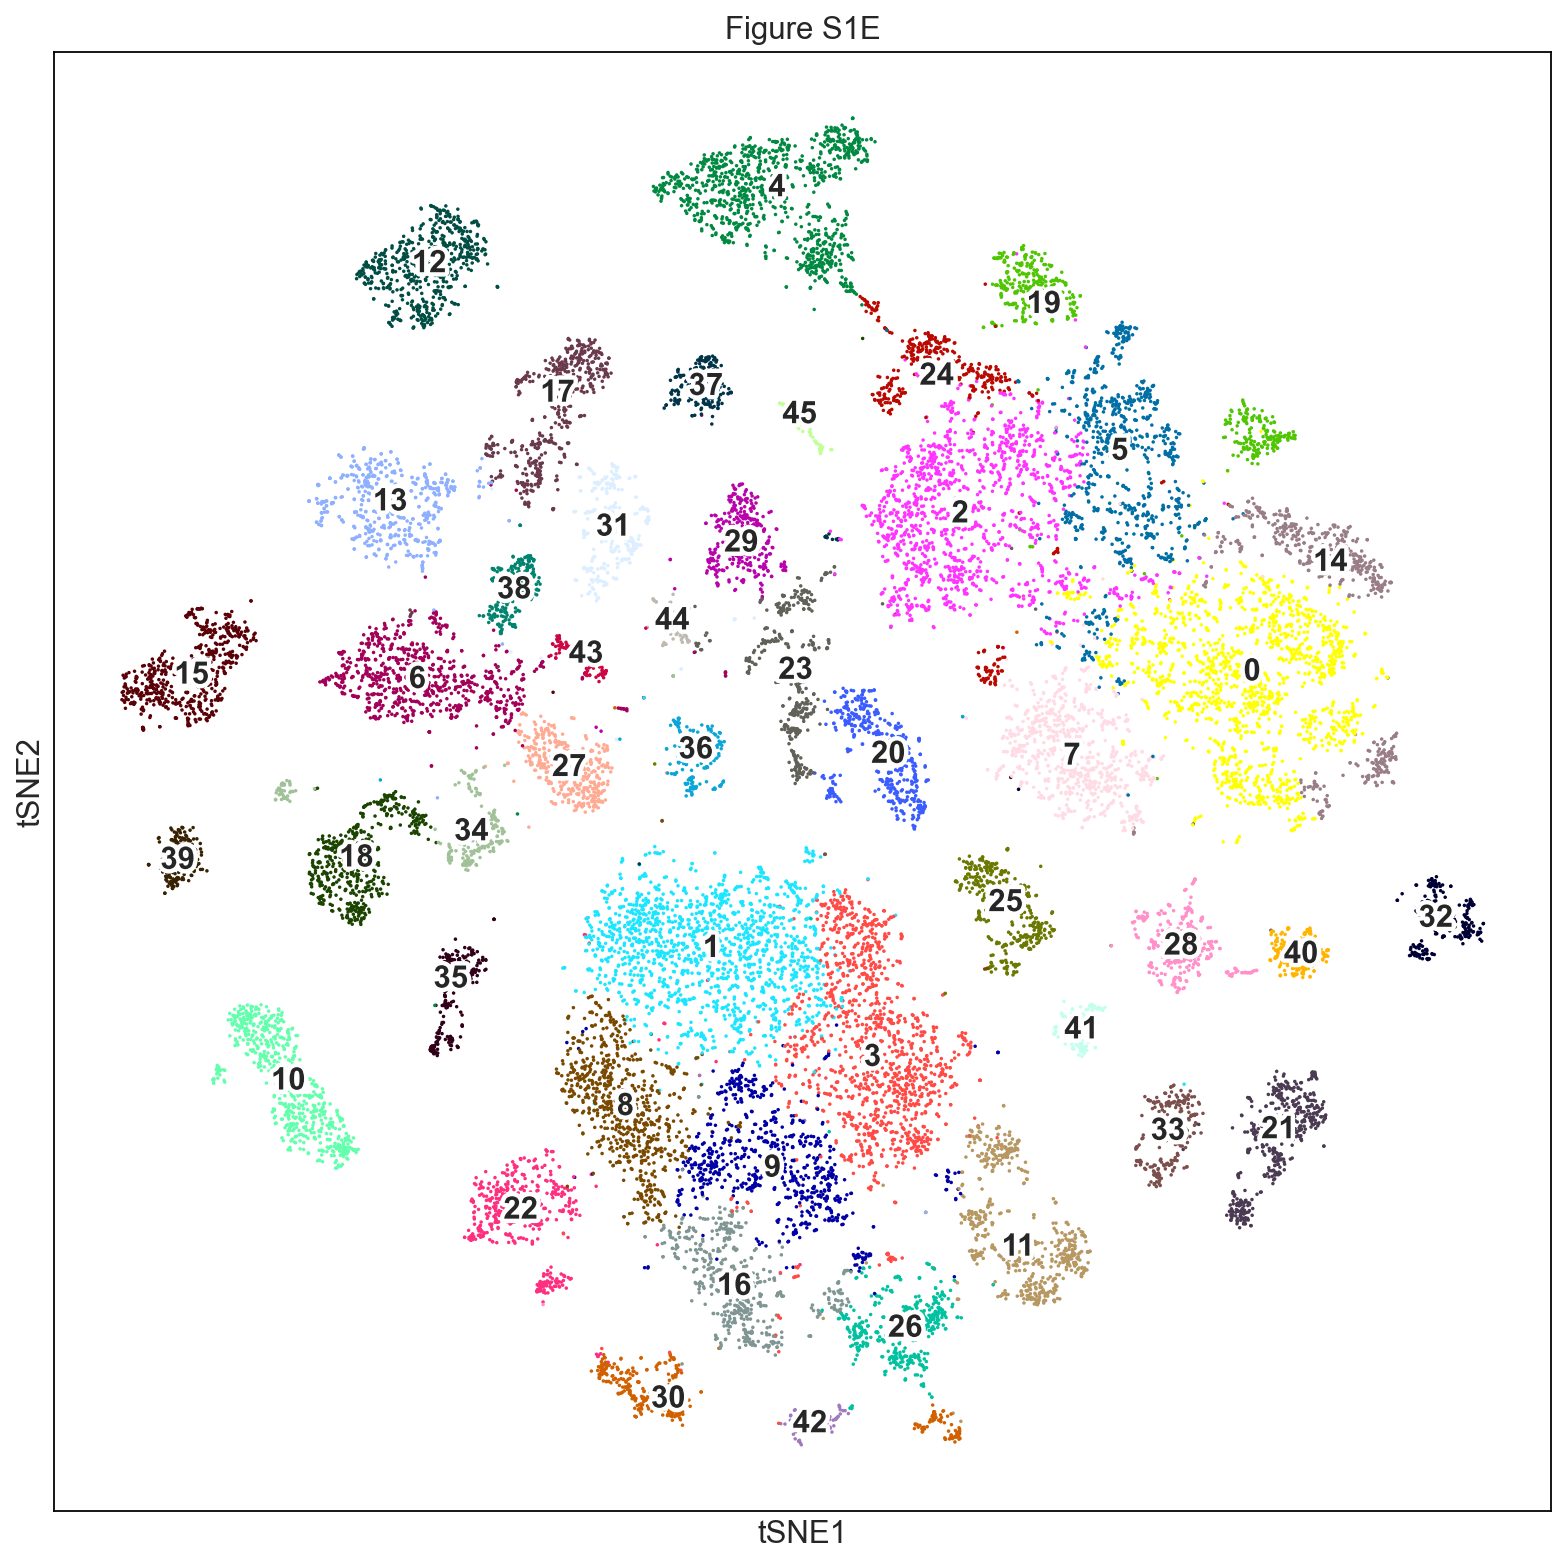

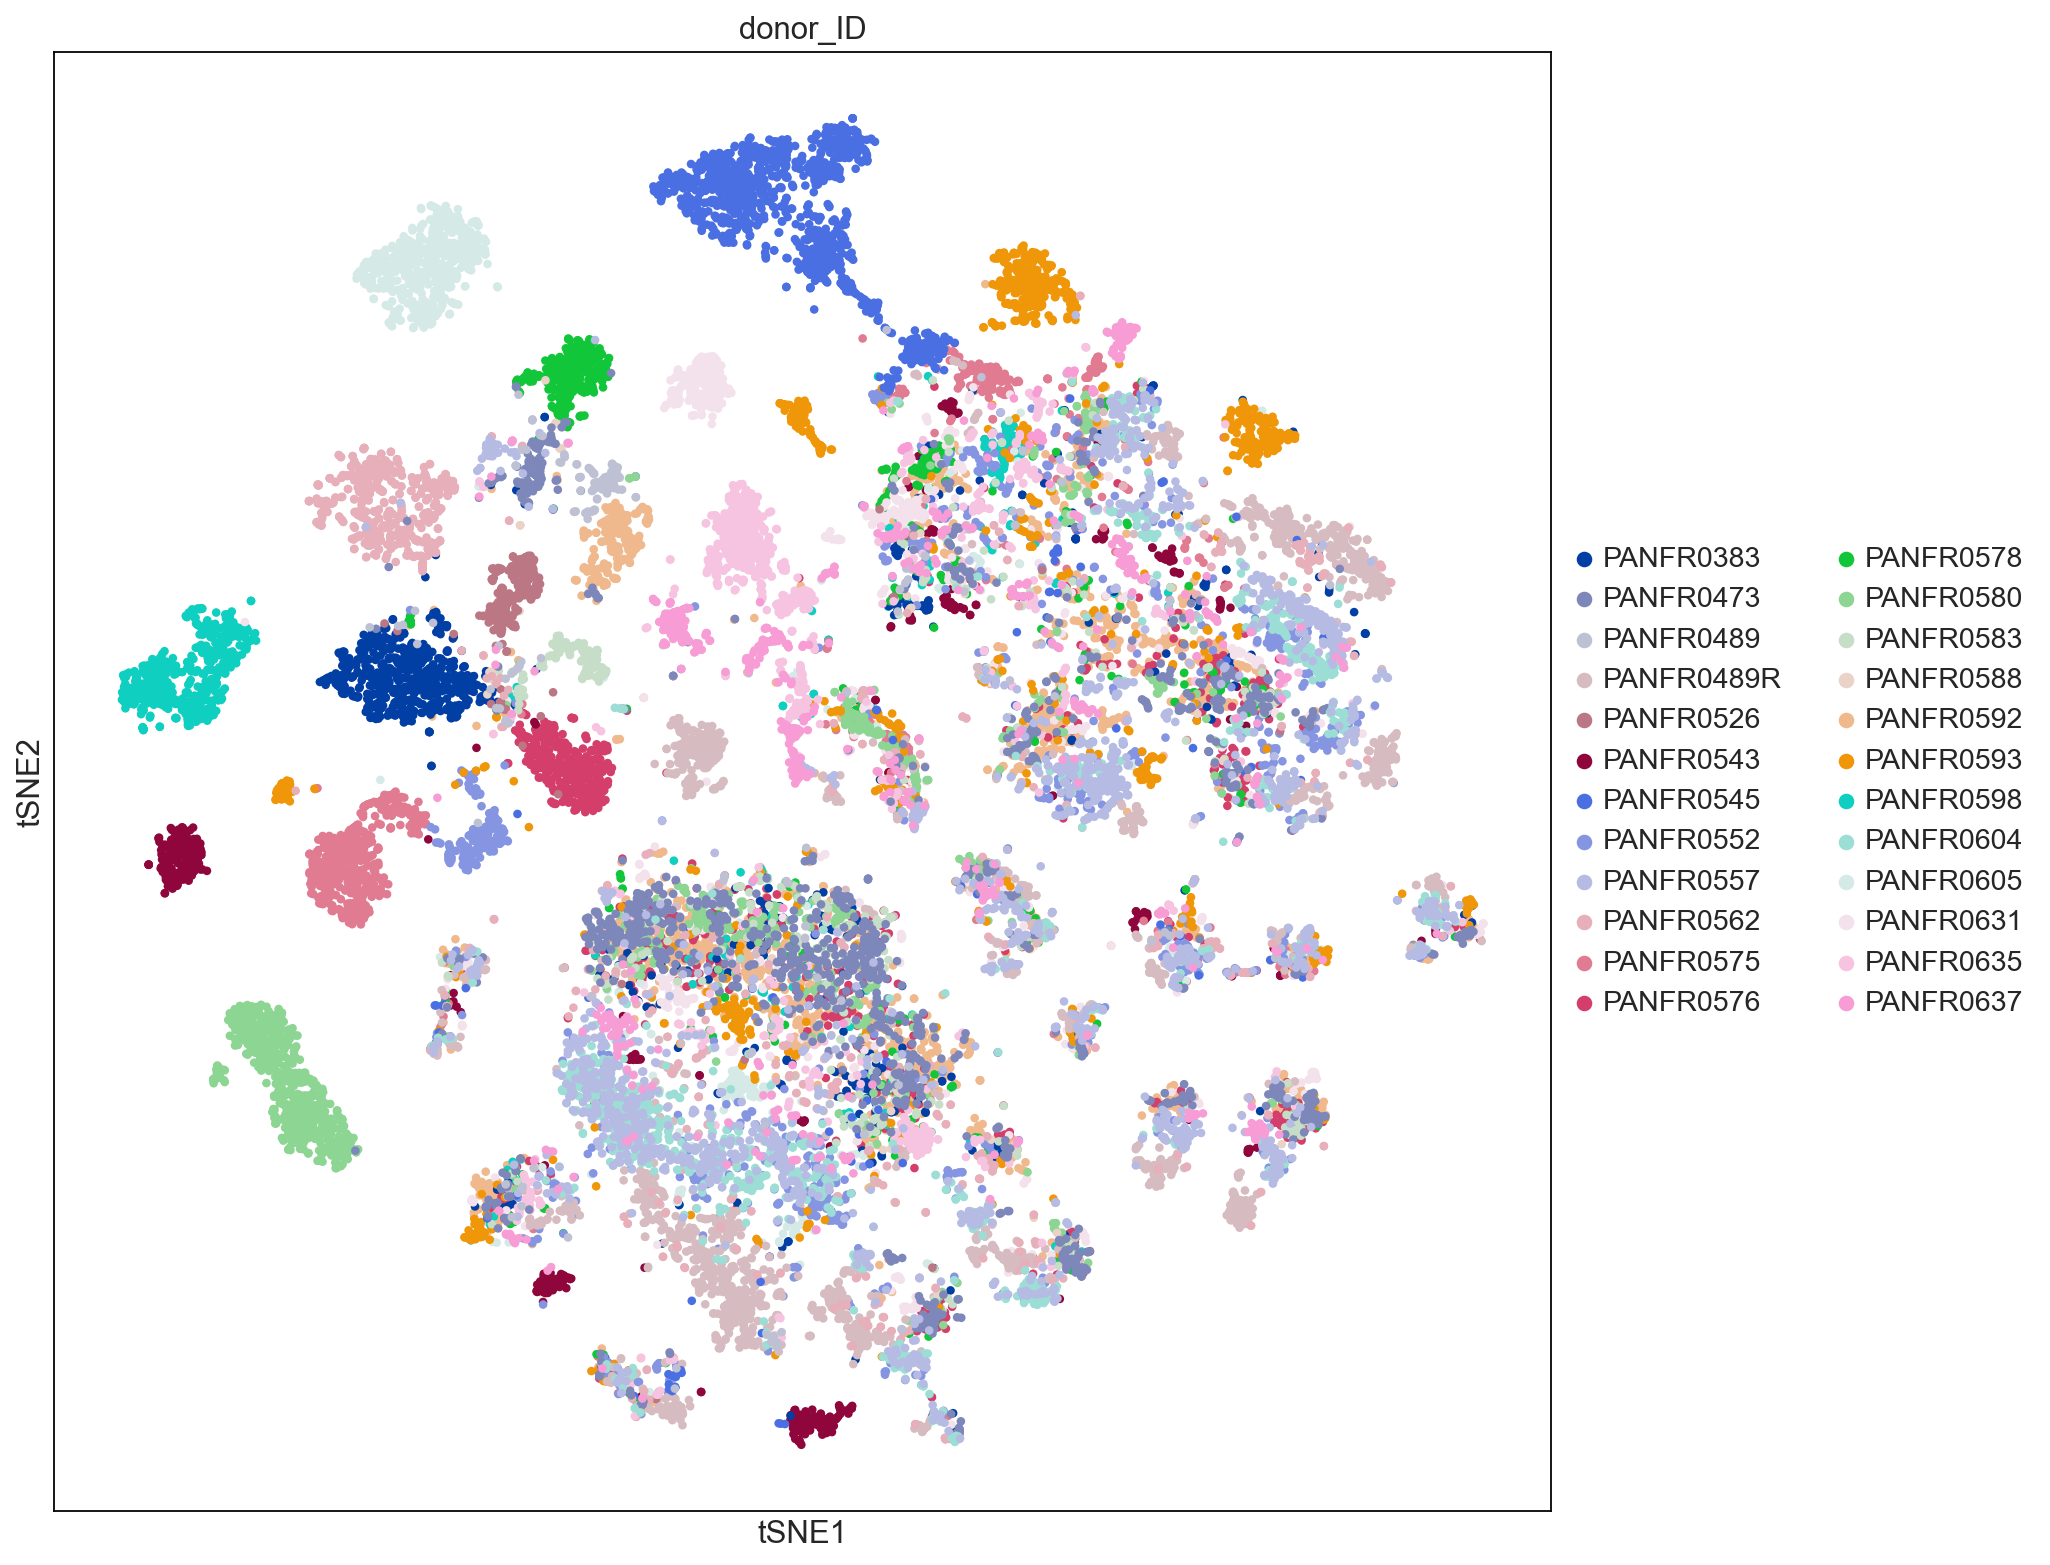

In [293]:
print("Final tSNE")
sc.pl.tsne(scp1644_filter, color=['leiden'], legend_loc="on data", legend_fontoutline=4, size=10, title='Figure S1E')
sc.pl.tsne(scp1644_filter, color='donor_ID', size=60)
plt.show()

In [84]:
print(leiden_to_cell_annot.to_dict()['local_cell_annot'])

{'0': 'Macrophage', '1': 'T_NK', '2': 'Macrophage', '3': 'T_NK', '4': 'Tumor', '5': 'Macrophage', '6': 'Tumor', '7': 'DC', '8': 'T_NK', '9': 'T_NK', '10': 'Tumor', '11': 'T_NK', '12': 'Tumor', '13': 'Tumor', '14': 'Macrophage', '15': 'Tumor', '16': 'T_NK', '17': 'Tumor', '18': 'Tumor', '19': 'Macrophage', '20': 'Mesenchymal', '21': 'B_Cells', '22': 'T_Regs', '23': 'Mesenchymal', '24': 'Macrophage', '25': 'Endothelial', '26': 'T_NK', '27': 'Tumor', '28': 'Plasma_cell', '29': 'Tumor', '30': 'T_NK', '31': 'Tumor', '32': 'pDC_cell', '33': 'B_Cells', '34': 'Tumor', '35': 'Hepatocyte', '36': 'Tumor', '37': 'Tumor', '38': 'Tumor', '39': 'Tumor', '40': 'Plasma_cell', '41': 'XCR1_DC', '42': 'T_NK', '43': 'Tumor', '44': 'Tumor', '45': 'Tumor'}


In [94]:
leiden_to_cell_annot = scp1644_filter.obs.groupby('leiden').agg({'local_cell_annot': 'first'})

cell_annot_to_leiden = {}
for k, v in leiden_to_cell_annot.to_dict()['local_cell_annot'].items():
    if v not in cell_annot_to_leiden:
        cell_annot_to_leiden[v] = [k]
    else:
        cell_annot_to_leiden[v].append(k)

print(cell_annot_to_leiden)
print(cell_annot_to_leiden.keys())
# print(scp1644_filter.obs.groupby('local_cell_annot').agg({'local_cell_annot': 'first'}))

{'Macrophage': ['0', '2', '5', '14', '19', '24'], 'T_NK': ['1', '3', '8', '9', '11', '16', '26', '30', '42'], 'Tumor': ['4', '6', '10', '12', '13', '15', '17', '18', '27', '29', '31', '34', '36', '37', '38', '39', '43', '44', '45'], 'DC': ['7'], 'Mesenchymal': ['20', '23'], 'B_Cells': ['21', '33'], 'T_Regs': ['22'], 'Endothelial': ['25'], 'Plasma_cell': ['28', '40'], 'pDC_cell': ['32'], 'Hepatocyte': ['35'], 'XCR1_DC': ['41']}
dict_keys(['Macrophage', 'T_NK', 'Tumor', 'DC', 'Mesenchymal', 'B_Cells', 'T_Regs', 'Endothelial', 'Plasma_cell', 'pDC_cell', 'Hepatocyte', 'XCR1_DC'])


<Figure size 1920x960 with 0 Axes>

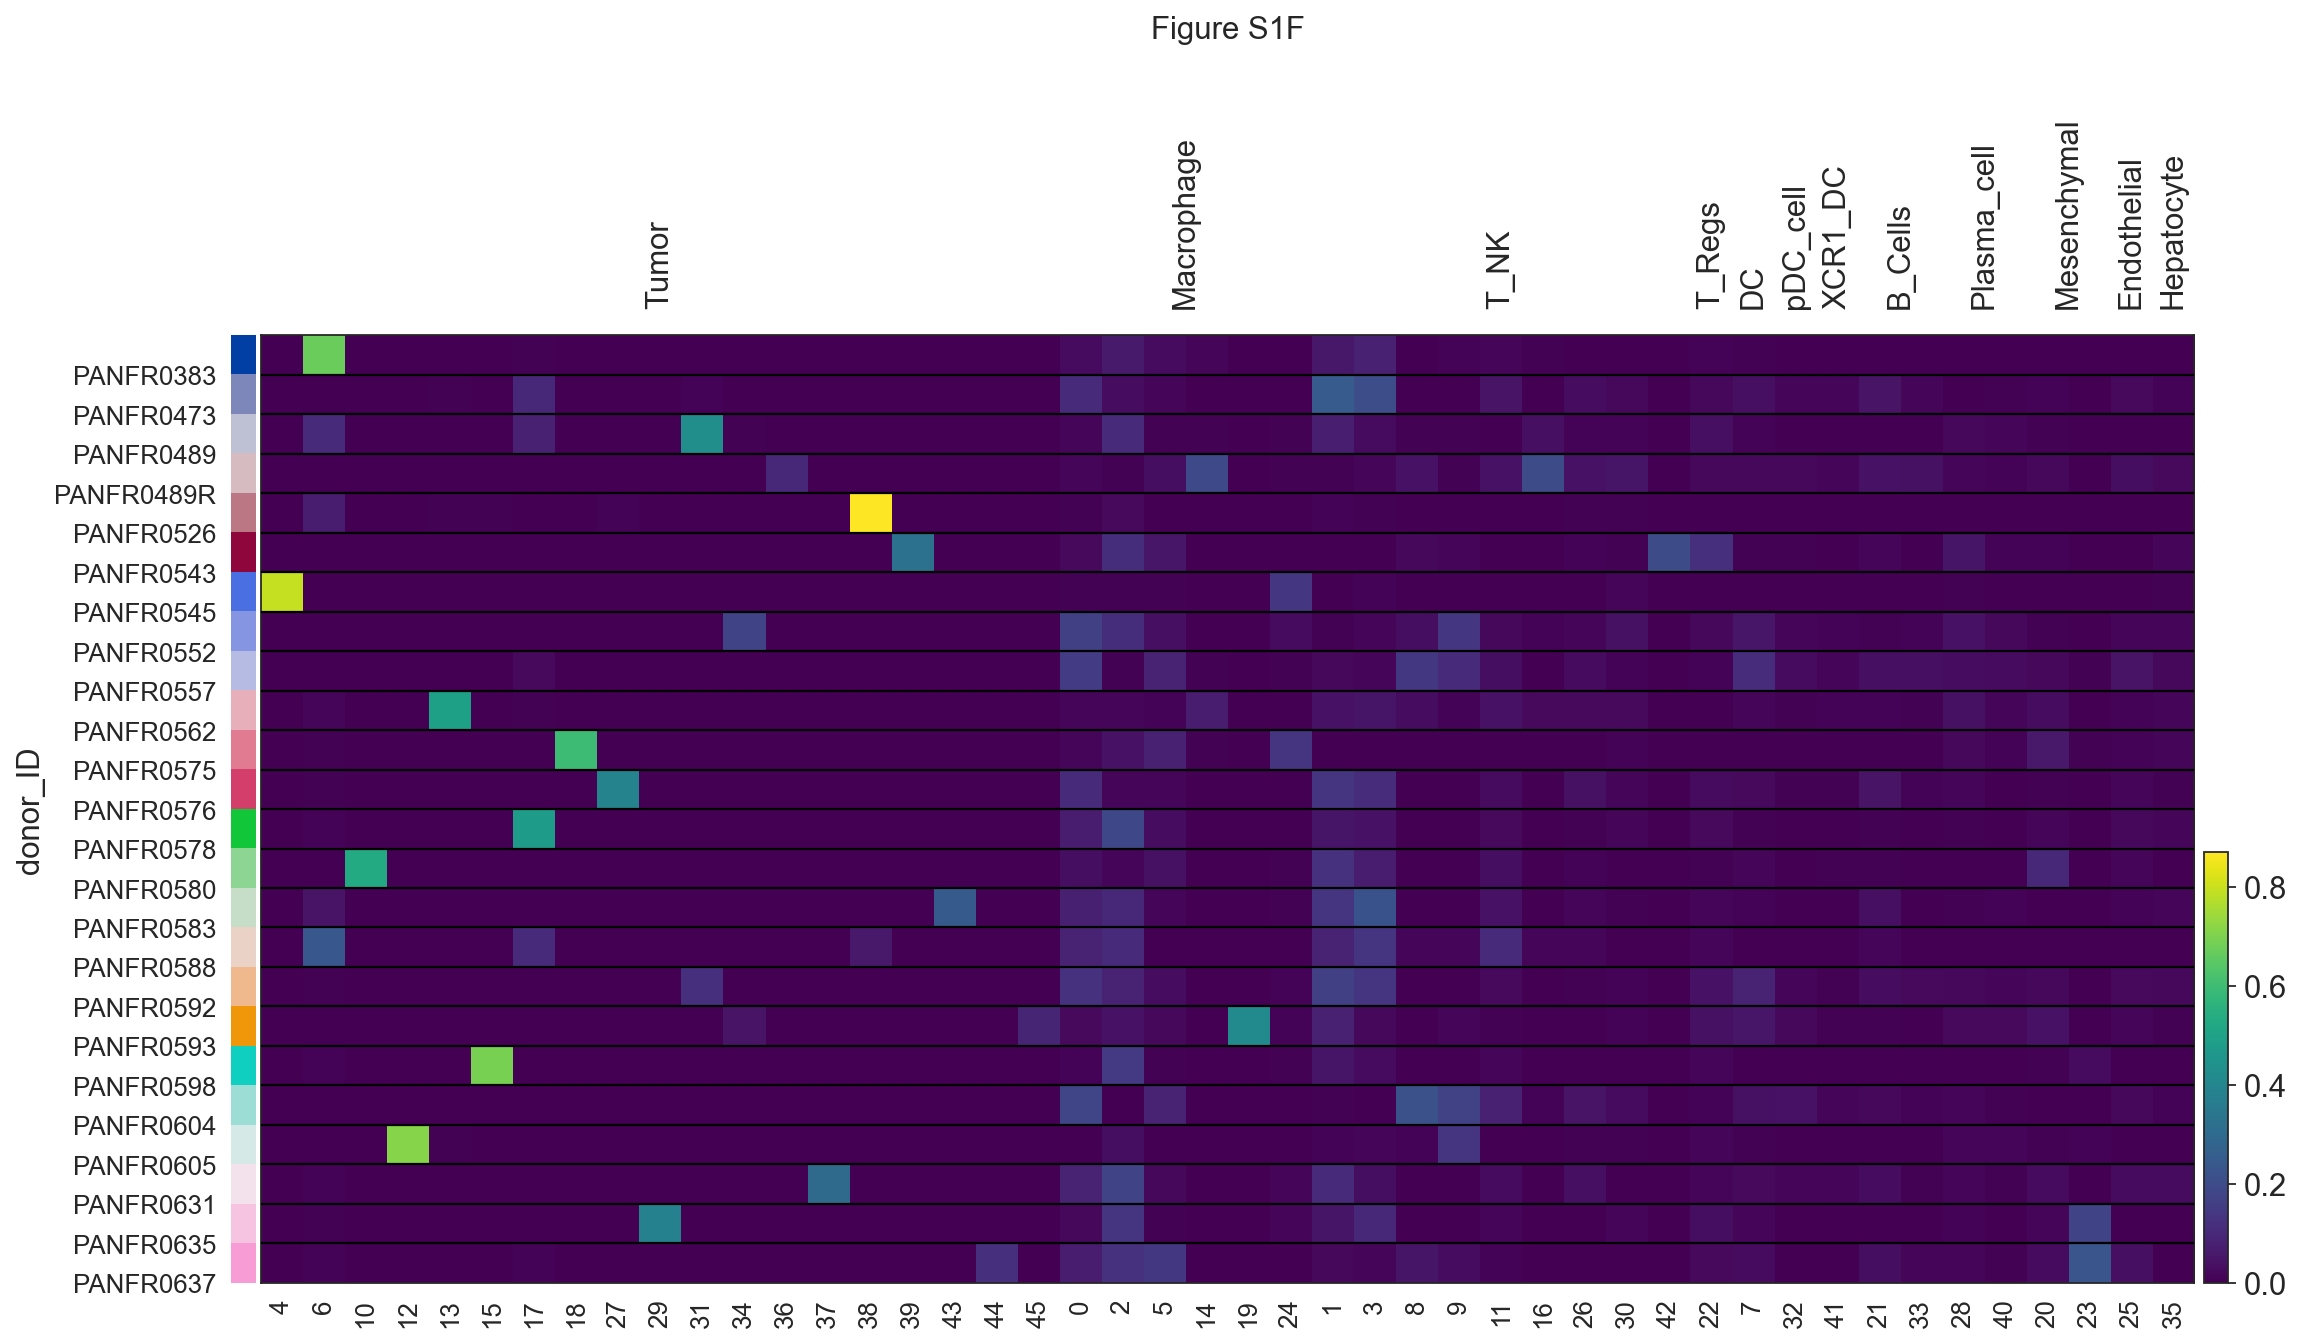

In [204]:
cluster_member_df = pd.DataFrame(0, index=sorted(scp1644_filter.obs.donor_ID.unique()), columns=sorted(scp1644_filter.obs.leiden.unique(), key=int))
categories = ['Tumor', 'Macrophage', 'T_NK', 'T_Regs', 'DC', 'pDC_cell', 'XCR1_DC', 'B_Cells', 'Plasma_cell', 'Mesenchymal',  'Endothelial', 'Hepatocyte']
new_cell_annot_to_leiden = {k: cell_annot_to_leiden[k] for k in categories}

for grpid, grp in scp1644_filter.obs.groupby(['donor_ID', 'leiden']):
    cluster_member_df.loc[grpid[0], grpid[1]] = len(grp)

cluster_member_df = cluster_member_df.T / cluster_member_df.T.sum(axis=0)

cluster_member_ad = ad.AnnData(cluster_member_df.T)
cluster_member_ad.obs['donor_ID'] = pd.Categorical(cluster_member_ad.obs_names)
cluster_member_ad.var['leiden'] = pd.Categorical(cluster_member_ad.var_names)


plt.figure(figsize=(24, 12))

sc.tl.dendrogram(cluster_member_ad, 'donor_ID')
ax = sc.pl.heatmap(cluster_member_ad, new_cell_annot_to_leiden, 'donor_ID', cmap='viridis', show=False, figsize=(16, 8))
ax['heatmap_ax'].set_title('Figure S1F', y=1.3)
ax['heatmap_ax'].grid(False)


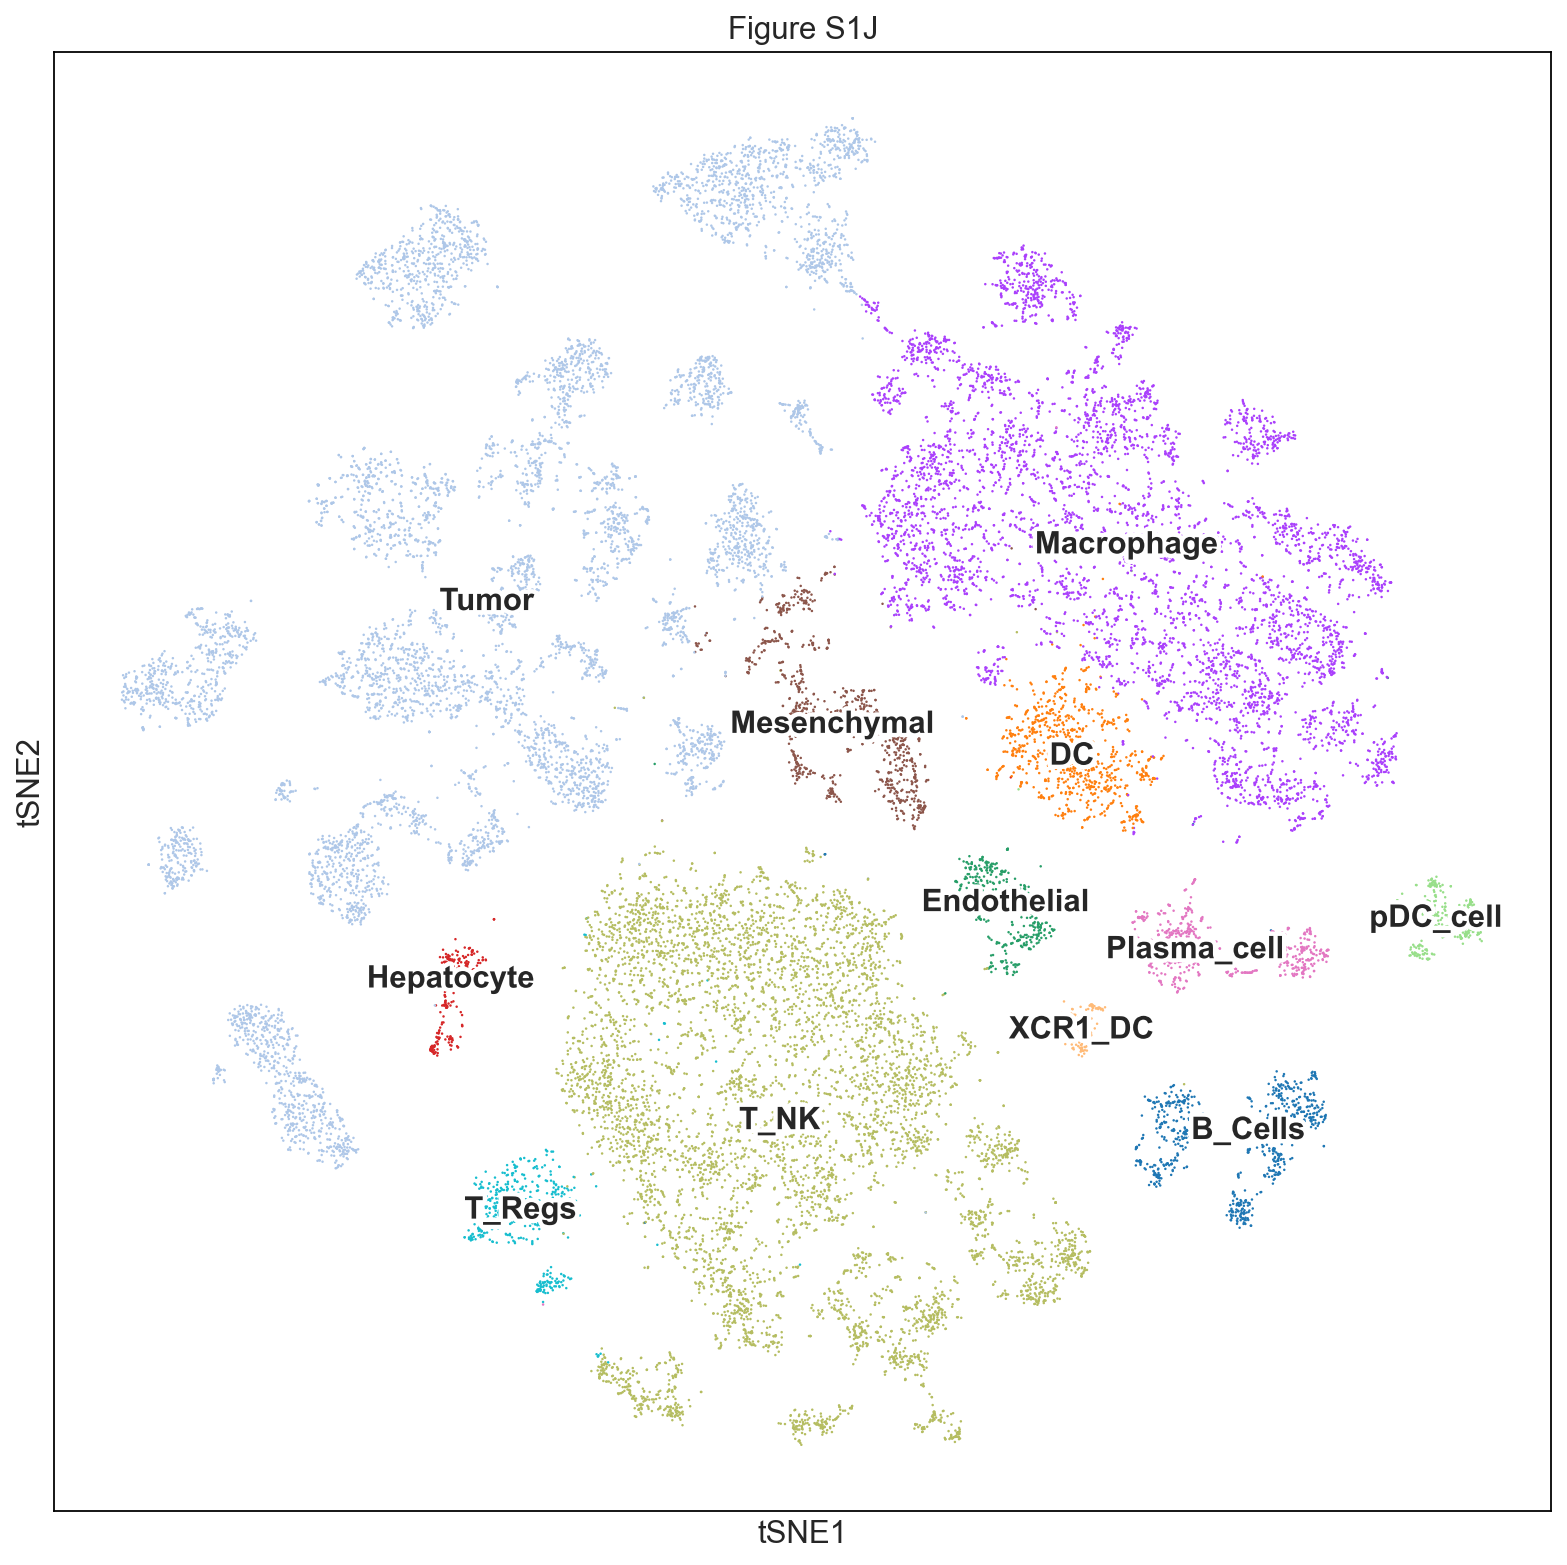

In [290]:
sc.set_figure_params(figsize=(12, 12))

ax = sc.pl.tsne(scp1644_filter, color='local_cell_annot', legend_loc="on data", legend_fontoutline=4, size=5, title='Figure S1J')


Text(0.5, 1.0, 'Figure S1K')

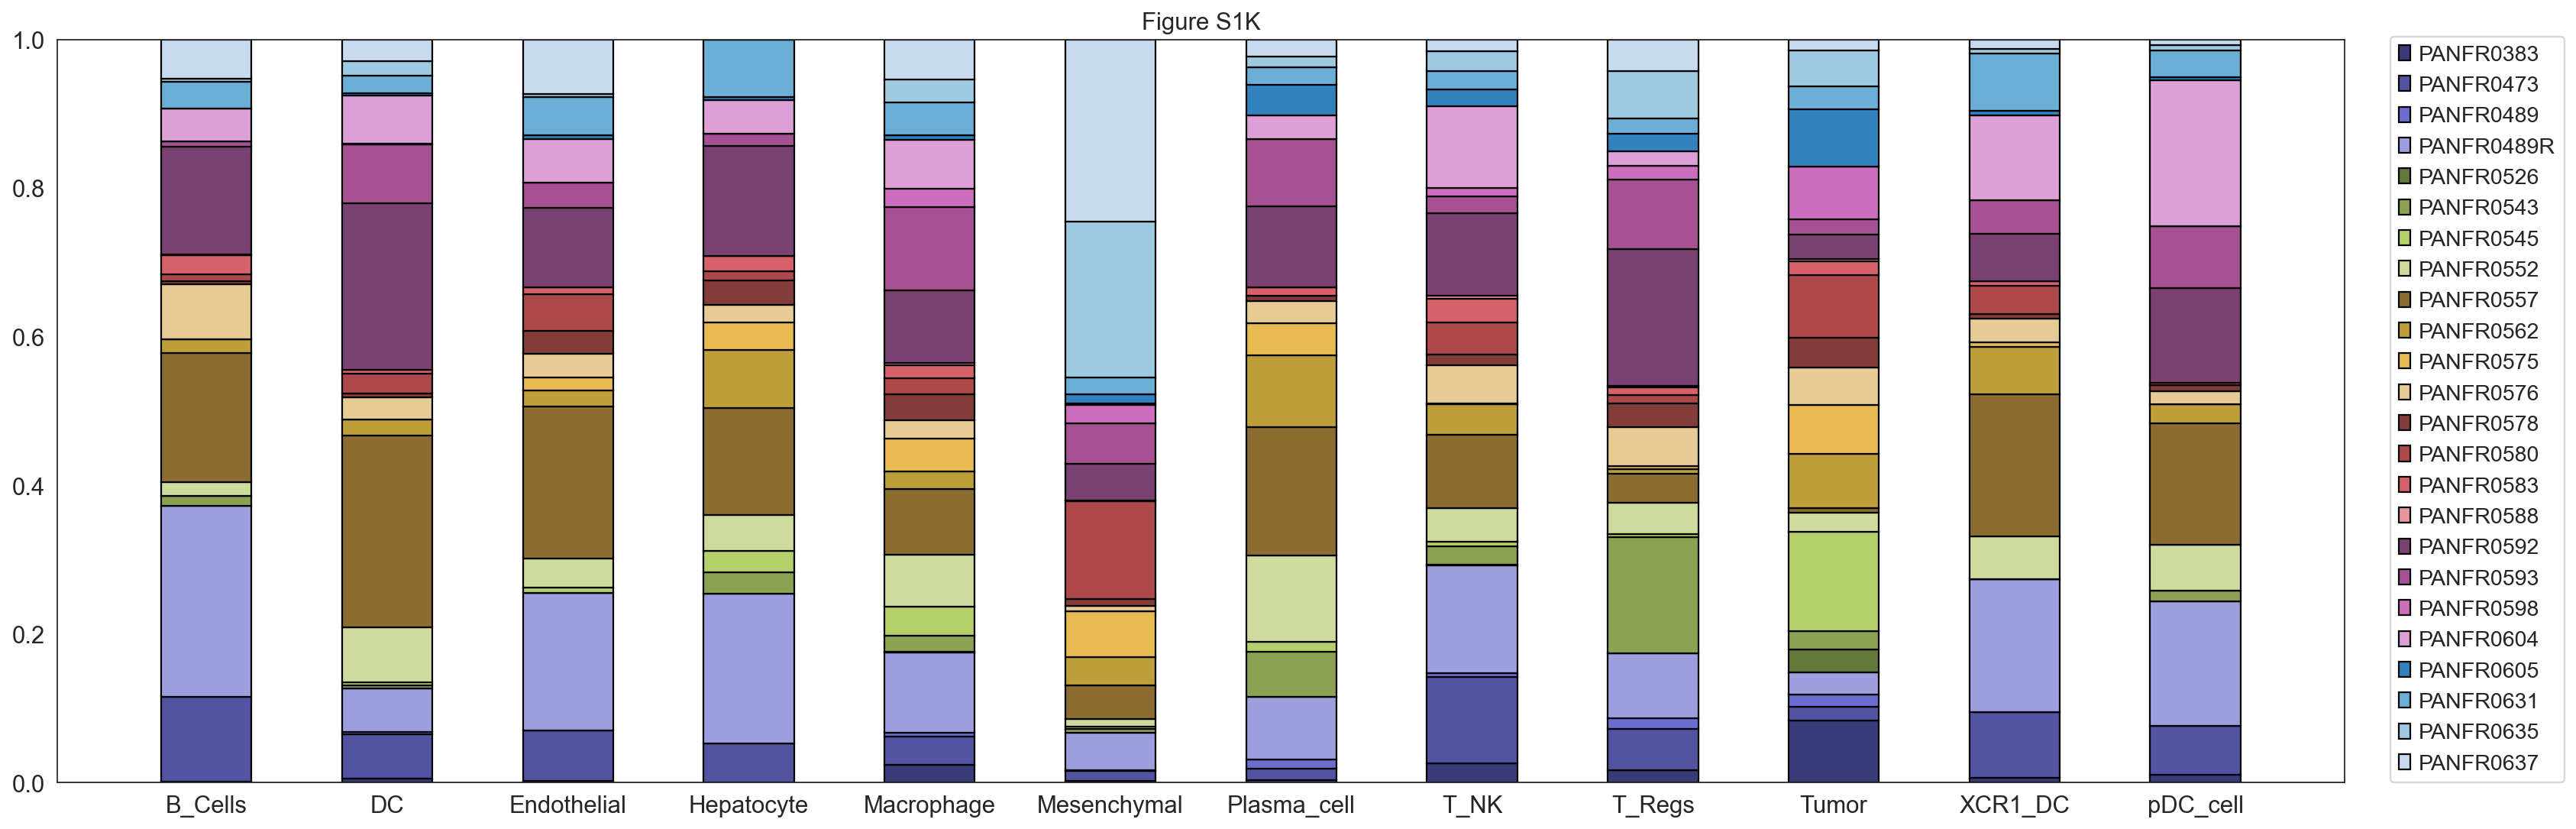

In [278]:
tmp = scp1644_filter.obs.groupby(['local_cell_annot', 'donor_ID']).agg({'donor_ID': 'count'})
tmp.columns = ['count']

tmp = tmp.reset_index()
tmp = tmp.pivot(index='donor_ID', columns='local_cell_annot')
tmp = tmp / tmp.sum(axis=0)
tmp.columns = tmp.columns.droplevel(0)

fig, ax = plt.subplots(figsize=(24, 8))
bottom = np.zeros(tmp.shape[1])
cm = iter(plt.get_cmap('tab20b').colors + plt.get_cmap('tab20c').colors)

for idx in tmp.index:
    p = ax.bar(tmp.columns, tmp.loc[idx, :], 0.5, label=idx, bottom=bottom, edgecolor='k', facecolor=cm.__next__())
    bottom += tmp.loc[idx, :]
ax.legend(loc=(1.02, 0))
plt.title('Figure S1K')

In [294]:
# cluster_member_df = pd.DataFrame(0, index=sorted(scp1644_filter.obs.donor_ID.unique()), columns=sorted(scp1644_filter.obs.leiden.unique(), key=int))

# for grpid, grp in scp1644_filter.obs.groupby(['donor_ID', 'leiden']):
#     cluster_member_df.loc[grpid[0], grpid[1]] = len(grp)

# # cluster_member_df = cluster_member_df / cluster_member_df.sum(axis=0)
# print(cluster_member_df)
# cluster_member_ad = ad.AnnData(cluster_member_df)

# # 
# plt.figure(figsize=(24, 12))

# ax = sns.clustermap(cluster_member_df, standard_scale=1, figsize=(24,12))
# sns.set_style('white')
# # plt.grid(False)
# # ax.grid(False)